## Шаг 0. Установка библиотек

In [1]:
!pip install -q lightgbm catboost xgboost optuna scikit-learn pandas numpy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 35.7 MB/s eta 0:00:00


## Шаг 1. Подготовка

In [2]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

import lightgbm as lgb
from catboost import CatBoostRegressor
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

TARGETS_REAL = ['IC50, mM', 'CC50, mM', 'SI']
TARGETS_OUT  = ['IC50', 'CC50', 'SI']

N_FOLDS = 10
SI_OUTLIER_THRESHOLD = 700
SEEDS = [42, 123, 777, 2024, 555, 1, 99, 314, 1000, 2048]

USE_LOG = {'IC50, mM': False, 'CC50, mM': True, 'SI': False}

sns.set_style('whitegrid')


## Шаг 2. Загрузка данных

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/'
train = pd.read_csv(DATA_DIR + 'train.csv')
test  = pd.read_csv(DATA_DIR + 'test.csv')


Mounted at /content/drive


In [4]:
train.head()


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [5]:
test.head()


,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,...,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,...,0,0,0,0,0,0,0,0,0,0
2,2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,...,0,0,0,0,0,0,0,0,0,0
3,3,14.061236,14.061236,0.054870,-6.660336,0.564307,23.464286,410.289,397.185,410.086525,...,0,0,0,0,0,0,0,0,0,0
4,4,12.790378,12.790378,0.320463,-1.642616,0.696213,22.000000,280.279,268.183,280.073559,...,0,0,0,0,0,0,0,0,0,0


In [6]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


In [7]:
test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Columns: 211 entries, index to fr_urea
dtypes: float64(104), int64(107)
memory usage: 412.2 KB


В train 751 строка и 214 признаков + 3 таргета. В test 250 строк, таргетов нет.

## Шаг 3. Анализ данных

### 3.1 Пропуски и дубликаты

In [8]:
#пропуски
print('пропуски train:')
print(train.isnull().sum()[train.isnull().sum() > 0])
print('итого:', train.isnull().sum().sum())


пропуски train:
MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64
итого: 24


In [9]:
print('пропуски test:')
print(test.isnull().sum()[test.isnull().sum() > 0])
print('итого:', test.isnull().sum().sum())


пропуски test:
MaxPartialCharge       1
MinPartialCharge       1
MaxAbsPartialCharge    1
MinAbsPartialCharge    1
BCUT2D_MWHI            1
BCUT2D_MWLOW           1
BCUT2D_CHGHI           1
BCUT2D_CHGLO           1
BCUT2D_LOGPHI          1
BCUT2D_LOGPLOW         1
BCUT2D_MRHI            1
BCUT2D_MRLOW           1
dtype: int64
итого: 12


Пропуски есть в признаках, заполним медианой при предобработке.

In [10]:
# дубликаты
print('дубликаты train:', train.duplicated().sum())
print('дубликаты test: ', test.duplicated().sum())


дубликаты train: 0
дубликаты test:  0


### 3.2 Статистика таргетов

In [11]:
train[TARGETS_REAL].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
"IC50, mM",751.0,204.54,370.37,0.00,13.22,44.07,206.79,4095.19
"CC50, mM",751.0,577.43,641.52,0.70,100.00,376.58,877.51,4538.98
SI,751.0,89.15,788.88,0.01,1.50,4.00,17.37,15620.60


Видно что у SI очень большое стандартное отклонение и есть сильные выбросы (макс 15620).
CC50 и IC50 тоже имеют правостороннее распределение.


### 3.3 Распределение таргетов

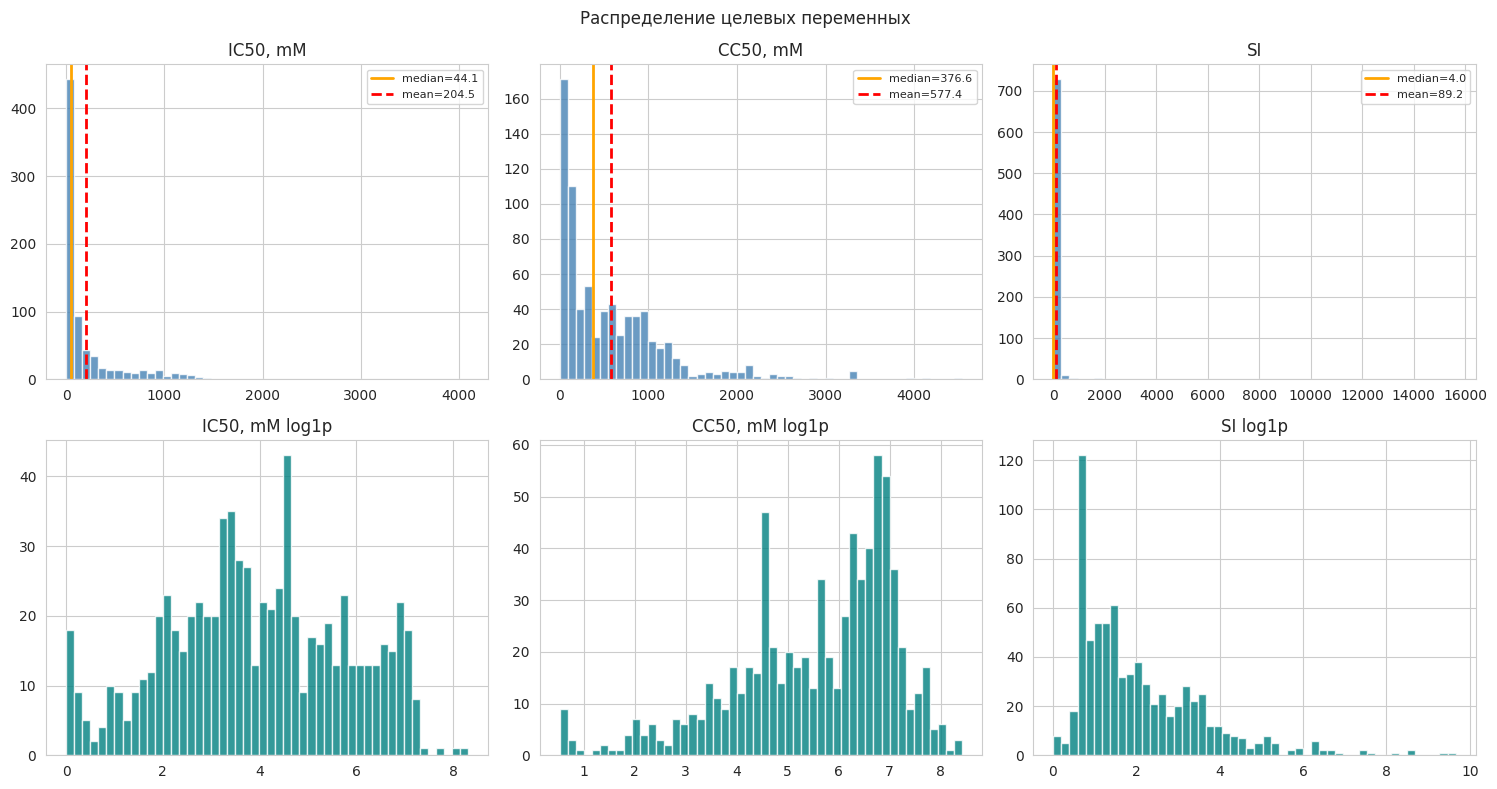

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(TARGETS_REAL):
    data = train[col].dropna()

    axes[0, i].hist(data, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
    axes[0, i].axvline(data.median(), color='orange', lw=2, label=f'median={data.median():.1f}')
    axes[0, i].axvline(data.mean(), color='red', lw=2, ls='--', label=f'mean={data.mean():.1f}')
    axes[0, i].set_title(col)
    axes[0, i].legend(fontsize=8)

    axes[1, i].hist(np.log1p(data), bins=50, color='teal', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'{col} log1p')

plt.suptitle('Распределение целевых переменных')
plt.tight_layout()
plt.show()


После log1p распределения становятся более симметричными.
Решено использовать log1p для CC50 при обучении потосу что у него самое правостороннее распределение.


### 3.4 Выбросы в таргетах

In [13]:
for col in TARGETS_REAL:
    q99 = train[col].quantile(0.99)
    n_out = (train[col] > q99).sum()
    print(f'{col}: 99-й перцентиль={q99:.1f}, выбросов={n_out}')


IC50, mM: 99-й перцентиль=1334.3, выбросов=8
CC50, mM: 99-й перцентиль=3162.0, выбросов=8
SI: 99-й перцентиль=1281.2, выбросов=8


In [14]:
print('выбросы SI > 700:')
print(train[train['SI'] > 700]['SI'].sort_values(ascending=False))


выбросы SI > 700:
663    15620.600000
434    11848.333333
492     5687.000000
92      5000.000000
91      4001.700000
254     1952.562500
699     1618.888889
142     1562.500000
595     1000.000000
400      828.935484
722      807.725806
Name: SI, dtype: float64


### 3.5 Корреляции между таргетами

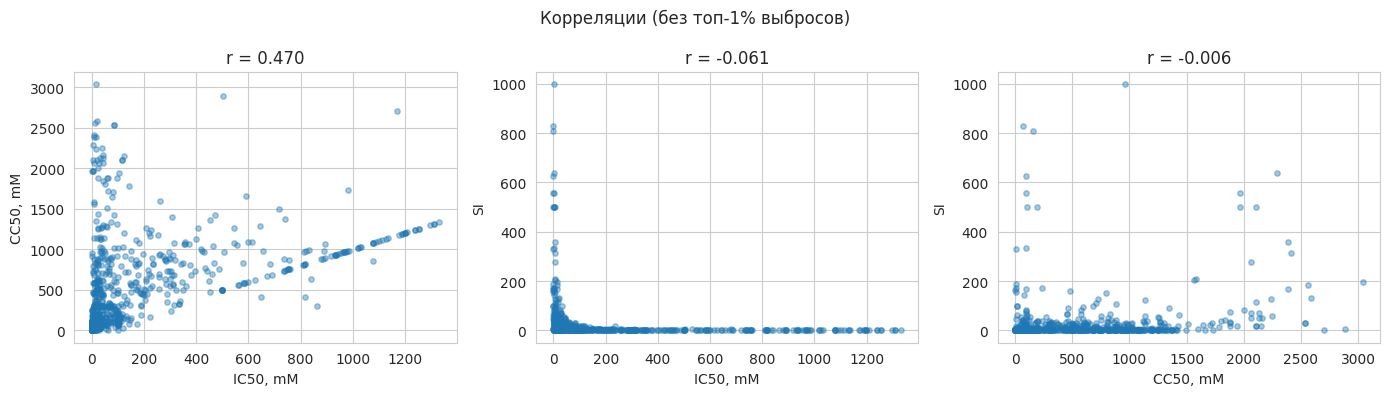

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [('IC50, mM', 'CC50, mM'), ('IC50, mM', 'SI'), ('CC50, mM', 'SI')]

for ax, (x, y) in zip(axes, pairs):
    mask = (train[x] < train[x].quantile(0.99)) & (train[y] < train[y].quantile(0.99))
    ax.scatter(train.loc[mask, x], train.loc[mask, y], alpha=0.4, s=15)
    r = train[[x, y]].corr().iloc[0, 1]
    ax.set_title(f'r = {r:.3f}')
    ax.set_xlabel(x)
    ax.set_ylabel(y)

plt.suptitle('Корреляции (без топ-1% выбросов)')
plt.tight_layout()
plt.show()


In [16]:
train[TARGETS_REAL].corr().round(3)


,"IC50, mM","CC50, mM",SI
"IC50, mM",1.000,0.470,-0.061
"CC50, mM",0.470,1.000,-0.006
SI,-0.061,-0.006,1.000


IC50 и CC50 коррелируют умеренно и это логично, оба показывают концентрацию.
SI слабо коррелирует с остальными  и предсказывать его будет сложнее.


### 3.6 Проверка схожести train и test

In [17]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

feat_cols_all = [c for c in train.columns if c not in TARGETS_REAL + ['index']]
common = [c for c in feat_cols_all if c in test.columns]

X_adv = pd.concat([train[common].fillna(0), test[common].fillna(0)], ignore_index=True)
y_adv = np.array([0] * len(train) + [1] * len(test))

clf = GradientBoostingClassifier(n_estimators=100, random_state=SEED)
aucs = []
for tri, vali in KFold(5, shuffle=True, random_state=SEED).split(X_adv):
    clf.fit(X_adv.iloc[tri], y_adv[tri])
    aucs.append(roc_auc_score(y_adv[vali], clf.predict_proba(X_adv.iloc[vali])[:, 1]))

print(f'AUC = {np.mean(aucs):.4f} +- {np.std(aucs):.4f}')
if np.mean(aucs) < 0.55:
    print('train и test из одного распределения, CV надёжен')
else:
    print('внимание: train и test заметно отличаются')


AUC = 0.4942 +- 0.0349
train и test из одного распределения, CV надёжен


### 3.7 Анализ признаков

In [18]:
feat_cols_raw = [c for c in train.columns if c not in TARGETS_REAL + ['index']]
print('всего признаков:', len(feat_cols_raw))

# константные
const = [c for c in feat_cols_raw if train[c].nunique() <= 1]
print('константных признаков:', len(const))

# признаков с более чем 90% нулей
zero_pct = (train[feat_cols_raw] == 0).mean()
print('признаков с >90% нулей:', (zero_pct > 0.9).sum())


всего признаков: 210
константных признаков: 18
признаков с >90% нулей: 69


In [19]:
# группы дескрипторов
prefixes = ['PEOE_VSA', 'SlogP_VSA', 'EState_VSA', 'BCUT2D', 'Chi', 'Kappa', 'fr_', 'SMR_VSA']
for pref in prefixes:
    cnt = sum(1 for c in feat_cols_raw if c.startswith(pref))
    if cnt > 0:
        print(f'{pref}: {cnt} признаков')


PEOE_VSA: 14 признаков
SlogP_VSA: 12 признаков
EState_VSA: 11 признаков
BCUT2D: 8 признаков
Chi: 12 признаков
Kappa: 3 признаков
fr_: 85 признаков
SMR_VSA: 10 признаков


## Шаг 4. Предобработка данных

In [20]:
feat_cols = [c for c in train.columns if c not in TARGETS_REAL + ['index']]
medians = train[feat_cols].median()

X_tr = train[feat_cols].fillna(medians).copy()
X_te = test[[c for c in feat_cols if c in test.columns]].fillna(medians).copy()
y_tr = train[TARGETS_REAL].copy()

n0 = X_tr.shape[1]
print('исходно признаков:', n0)


исходно признаков: 210


In [21]:
# удаляем константные признаки
vt = VarianceThreshold(0.0)
vt.fit(X_tr)
X_tr = X_tr.loc[:, vt.get_support()]
X_te = X_te.loc[:, vt.get_support()]
print('после удаления константных:', X_tr.shape[1])


после удаления константных: 192


In [22]:
# Дублирующиеся столбцы
dup = X_tr.T.duplicated()
X_tr = X_tr.loc[:, ~dup]
X_te = X_te.loc[:, ~dup]
print('после удаления дублей:', X_tr.shape[1])


после удаления дублей: 186


In [23]:
# удаляем сильно коррелирующие признаки (corr > 0.95)
corr_m = X_tr.corr().abs()
upper = corr_m.where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
X_tr = X_tr.drop(columns=to_drop)
X_te = X_te.drop(columns=to_drop)
print('после удаления коррелированных:', X_tr.shape[1])
print('итого удалено:', n0 - X_tr.shape[1])


после удаления коррелированных: 159
итого удалено: 51


## Шаг 5. Создание новых признаков

In [24]:
cols = X_tr.columns.tolist()

def add_features(df, cols):
    # Соотношения молекулярных свойств
    if 'MolWt' in cols and 'MolLogP' in cols:
        df['MolWt_LogP'] = df['MolWt'] / (df['MolLogP'].abs() + 1e-6)
    if 'TPSA' in cols and 'MolWt' in cols:
        df['TPSA_MolWt'] = df['TPSA'] / (df['MolWt'] + 1e-6)
    if 'MolLogP' in cols and 'HeavyAtomCount' in cols:
        df['LogP_Heavy'] = df['MolLogP'] * df['HeavyAtomCount']
    if 'MaxPartialCharge' in cols and 'MinPartialCharge' in cols:
        df['ChargeRange'] = df['MaxPartialCharge'] - df['MinPartialCharge']
    if 'NumHAcceptors' in cols and 'NumHDonors' in cols:
        df['HBond_total'] = df['NumHAcceptors'] + df['NumHDonors']
    if 'NumRotatableBonds' in cols and 'RingCount' in cols:
        df['Flexibility'] = df['NumRotatableBonds'] / (df['RingCount'] + 1)

    # функциональные группы
    fr = [c for c in cols if c.startswith('fr_')]
    if fr:
        df['fr_total'] = df[fr].sum(axis=1)
        df['fr_nonzero'] = (df[fr] > 0).sum(axis=1)

    # агрегаты по группам дескрипторов
    for prefix in ['PEOE_VSA', 'SlogP_VSA', 'EState_VSA', 'VSA_EState', 'BCUT2D_', 'SMR_VSA']:
        grp = [c for c in cols if c.startswith(prefix)]
        if grp:
            df[f'{prefix}sum']  = df[grp].sum(axis=1)
            df[f'{prefix}mean'] = df[grp].mean(axis=1)
            df[f'{prefix}std']  = df[grp].std(axis=1)
            df[f'{prefix}max']  = df[grp].max(axis=1)

    chi = [c for c in cols if c.startswith('Chi')]
    if chi:
        df['Chi_sum'] = df[chi].sum(axis=1)
        df['Chi_mean'] = df[chi].mean(axis=1)

    kappa = [c for c in cols if c.startswith('Kappa')]
    if kappa:
        df['Kappa_mean'] = df[kappa].mean(axis=1)

    # взаимодействия признаков
    if 'Chi1n' in cols and 'MaxPartialCharge' in cols:
        df['Chi1n_x_MaxPC'] = df['Chi1n'] * df['MaxPartialCharge']
    if 'qed' in cols and 'BalabanJ' in cols:
        df['qed_x_Balaban'] = df['qed'] * df['BalabanJ']
    if 'BCUT2D_CHGLO' in cols and 'BCUT2D_MRLOW' in cols:
        df['BCUT_chglo_mrlow'] = df['BCUT2D_CHGLO'] * df['BCUT2D_MRLOW']
    if 'MolWt' in cols and 'TPSA' in cols:
        df['MolWt_x_TPSA'] = df['MolWt'] * df['TPSA']

    df.fillna(0, inplace=True)
    return df

for df in [X_tr, X_te]:
    add_features(df, cols)

print('признаков после FE:', X_tr.shape[1])


признаков после FE: 195


### 5.1 Кластеризация молекул

Молекулы можно группировать по химической структуре.
Добавим номер кластера и расстояния до каждого центроида как признаки.


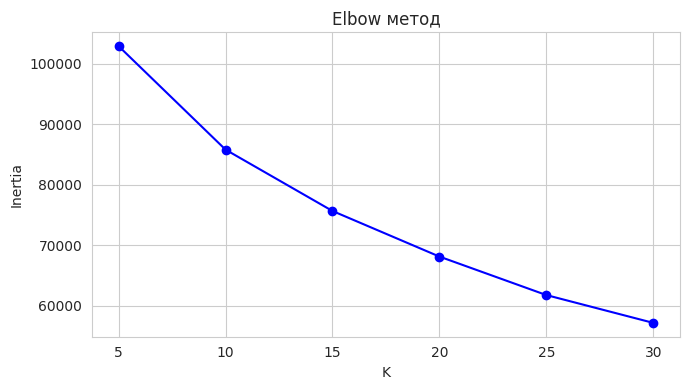

In [25]:
scaler_cluster = StandardScaler()
X_tr_scaled_base = scaler_cluster.fit_transform(X_tr)
X_te_scaled_base = scaler_cluster.transform(X_te)

inertias = []
K_range = range(5, 31, 5)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_tr_scaled_base)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, 'bo-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow метод')
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
BEST_K = 15
km_final = KMeans(n_clusters=BEST_K, random_state=SEED, n_init=10)
X_tr['cluster'] = km_final.fit_predict(X_tr_scaled_base)
X_te['cluster'] = km_final.predict(X_te_scaled_base)

dist_tr = km_final.transform(X_tr_scaled_base)
dist_te = km_final.transform(X_te_scaled_base)
for i in range(BEST_K):
    X_tr[f'dist_cluster_{i}'] = dist_tr[:, i]
    X_te[f'dist_cluster_{i}'] = dist_te[:, i]
X_tr['min_cluster_dist'] = dist_tr.min(axis=1)
X_te['min_cluster_dist'] = dist_te.min(axis=1)

print('признаков после кластеризации:', X_tr.shape[1])


признаков после кластеризации: 212


### 5.2 PCA

In [27]:
# пересчитываем scaler уже с кластерными признаками
scaler_pca = StandardScaler()
X_tr_scaled = scaler_pca.fit_transform(X_tr)
X_te_scaled = scaler_pca.transform(X_te)

N_PCA = 15
pca = PCA(n_components=N_PCA, random_state=SEED)
pca_tr = pca.fit_transform(X_tr_scaled)
pca_te = pca.transform(X_te_scaled)

for i in range(N_PCA):
    X_tr[f'pca_{i}'] = pca_tr[:, i]
    X_te[f'pca_{i}'] = pca_te[:, i]

print('итого признаков:', X_tr.shape[1])
print(f'PCA объясняет {pca.explained_variance_ratio_.sum()*100:.1f}% дисперсии')


итого признаков: 227
PCA объясняет 70.5% дисперсии


## Шаг 6. Метрика

In [28]:
def rmse(a, b):
    return np.sqrt(mean_squared_error(np.array(a), np.array(b)))


## Шаг 7. Подбор гиперпараметров

Используем Optuna с 3-Fold CV для скорости.
Финальное обучение 10-Fold.
Для CC50 оцениваем в оригинальном пространстве (expm1 после log предсказания).


In [29]:
OPTUNA_TRIALS_LGB = 60
OPTUNA_TRIALS_CAT = 25

KF_TUNE = KFold(n_splits=3, shuffle=True, random_state=SEED)

def tune_target(t_r, n_lgb=OPTUNA_TRIALS_LGB, n_cat=OPTUNA_TRIALS_CAT):
    use_log = USE_LOG[t_r]
    si_filt = (t_r == 'SI')
    y_raw = y_tr[t_r].copy()
    y_fit = np.log1p(y_raw) if use_log else y_raw

    def run_folds(train_fn):
        scores = []
        for tri, vali in KF_TUNE.split(X_tr):
            Xt_f = X_tr.iloc[tri]
            yt_f = y_fit.iloc[tri]
            Xv   = X_tr.iloc[vali]
            yv_f = y_fit.iloc[vali]
            yv_r = y_raw.iloc[vali]
            if si_filt:
                keep = y_raw.iloc[tri] < SI_OUTLIER_THRESHOLD
                Xt, yt = Xt_f[keep], yt_f[keep]
            else:
                Xt, yt = Xt_f, yt_f
            scores.append(train_fn(Xt, yt, Xv, yv_f, yv_r))
        return np.mean(scores)

    def obj_lgb(trial):
        params = dict(
            n_estimators      = trial.suggest_int('n_est', 300, 1500),
            learning_rate     = trial.suggest_float('lr', 0.005, 0.05, log=True),
            num_leaves        = trial.suggest_int('leaves', 20, 80),
            max_depth         = trial.suggest_int('depth', 4, 8),
            min_child_samples = trial.suggest_int('mcs', 5, 40),
            subsample         = trial.suggest_float('sub', 0.5, 1.0),
            colsample_bytree  = trial.suggest_float('col', 0.4, 1.0),
            reg_alpha         = trial.suggest_float('ra', 1e-4, 1.0, log=True),
            reg_lambda        = trial.suggest_float('rl', 1e-4, 1.0, log=True),
            random_state=SEED, n_jobs=-1, verbose=-1
        )
        def train_fn(Xt, yt, Xv, yv_f, yv_r):
            m = lgb.LGBMRegressor(**params)
            m.fit(Xt, yt, eval_set=[(Xv, yv_f)],
                  callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
            pred = m.predict(Xv)
            return rmse(yv_r, np.expm1(pred) if use_log else pred)
        return run_folds(train_fn)

    def obj_cat(trial):
        params = dict(
            iterations            = trial.suggest_int('iter', 200, 800),
            learning_rate         = trial.suggest_float('lr', 0.01, 0.1, log=True),
            depth                 = trial.suggest_int('depth', 4, 8),
            l2_leaf_reg           = trial.suggest_float('l2', 0.5, 10.0),
            early_stopping_rounds = 30,
            random_seed=SEED, verbose=0, thread_count=-1
        )
        def train_fn(Xt, yt, Xv, yv_f, yv_r):
            mc = CatBoostRegressor(**params)
            mc.fit(Xt, yt, eval_set=(Xv, yv_f), verbose=0)
            pred = mc.predict(Xv)
            return rmse(yv_r, np.expm1(pred) if use_log else pred)
        return run_folds(train_fn)

    print(f'  lgb ({n_lgb} trials)...')
    sl = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
    sl.optimize(obj_lgb, n_trials=n_lgb, show_progress_bar=True)

    print(f'  catboost ({n_cat} trials)...')
    sc = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
    sc.optimize(obj_cat, n_trials=n_cat, show_progress_bar=True)

    bp_l = sl.best_params
    bp_c = sc.best_params

    lgb_p = dict(
        n_estimators=bp_l['n_est'], learning_rate=bp_l['lr'],
        num_leaves=bp_l['leaves'], max_depth=bp_l['depth'],
        min_child_samples=bp_l['mcs'], subsample=bp_l['sub'],
        colsample_bytree=bp_l['col'], reg_alpha=bp_l['ra'],
        reg_lambda=bp_l['rl'], random_state=SEED, n_jobs=-1, verbose=-1
    )
    cat_p = dict(
        iterations=bp_c['iter'], learning_rate=bp_c['lr'],
        depth=bp_c['depth'], l2_leaf_reg=bp_c['l2'],
        random_seed=SEED, verbose=0, thread_count=-1
    )
    print(f'  {t_r}: lgb={sl.best_value:.2f} cat={sc.best_value:.2f}')
    return lgb_p, cat_p


print('подбор параметров...')
BEST_LGB, BEST_CAT = {}, {}
for t_r in TARGETS_REAL:
    print(f'{t_r}')
    lgb_p, cat_p = tune_target(t_r)
    BEST_LGB[t_r] = lgb_p
    BEST_CAT[t_r] = cat_p

print('готово')


подбор параметров...
IC50, mM
  lgb (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]

  catboost (25 trials)...


  0%|          | 0/25 [00:00<?, ?it/s]

  IC50, mM: lgb=316.70 cat=312.77
CC50, mM
  lgb (60 trials)...


...

  CC50, mM: lgb=506.96 cat=510.10
SI
  lgb (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]

  catboost (25 trials)...


  0%|          | 0/25 [00:00<?, ?it/s]

  SI: lgb=671.65 cat=671.96
готово


## Шаг 8. Обучение моделей

Ансамбль из трёх алгоритмов: LightGBM, CatBoost, XGBoost.
Финальные предсказанияRidge stacking на OOF предсказаниях трёх моделей.
Для SI при обучении убираем строки с SI >= 700


In [30]:
def get_xgb_params(lgb_p, seed):
    return dict(
        n_estimators     = lgb_p.get('n_estimators', 1000),
        learning_rate    = lgb_p.get('learning_rate', 0.01),
        max_depth        = min(lgb_p.get('max_depth', 6), 8),
        min_child_weight = max(lgb_p.get('min_child_samples', 10) // 5, 1),
        subsample        = lgb_p.get('subsample', 0.8),
        colsample_bytree = lgb_p.get('colsample_bytree', 0.7),
        reg_alpha        = lgb_p.get('reg_alpha', 0.01),
        reg_lambda       = lgb_p.get('reg_lambda', 0.1),
        random_state=seed, n_jobs=-1, verbosity=0, early_stopping_rounds=50
    )


def train_one_seed(X, y, Xte, t_r, lgb_params, cat_params, seed):
    kf_s = KFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    lp = dict(lgb_params, random_state=seed)
    cp = dict(cat_params, random_seed=seed)
    xp = get_xgb_params(lgb_params, seed)

    use_log   = USE_LOG[t_r]
    si_filter = (t_r == 'SI')

    oof_lgb = np.zeros(len(X))
    oof_cat = np.zeros(len(X))
    oof_xgb = np.zeros(len(X))
    te_lgb  = np.zeros(len(Xte))
    te_cat  = np.zeros(len(Xte))
    te_xgb  = np.zeros(len(Xte))

    y_raw = y.copy()
    y_fit = np.log1p(y_raw) if use_log else y_raw

    for tri, vali in kf_s.split(X):
        Xt_f = X.iloc[tri]
        yt_f = y_fit.iloc[tri]
        Xv   = X.iloc[vali]
        yv_f = y_fit.iloc[vali]
        yv_r = y_raw.iloc[vali]

        if si_filter:
            keep = y_raw.iloc[tri] < SI_OUTLIER_THRESHOLD
            Xt, yt = Xt_f[keep], yt_f[keep]
        else:
            Xt, yt = Xt_f, yt_f

        ml = lgb.LGBMRegressor(**lp)
        ml.fit(Xt, yt, eval_set=[(Xv, yv_f)],
               callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        pl_v = ml.predict(Xv)
        pl_t = ml.predict(Xte)

        mc = CatBoostRegressor(**cp)
        mc.fit(Xt, yt, eval_set=(Xv, yv_f), early_stopping_rounds=50, verbose=0)
        pc_v = mc.predict(Xv)
        pc_t = mc.predict(Xte)

        mx = xgb.XGBRegressor(**xp)
        mx.fit(Xt, yt, eval_set=[(Xv, yv_f)], verbose=False)
        px_v = mx.predict(Xv)
        px_t = mx.predict(Xte)

        if use_log:
            pl_v = np.expm1(pl_v); pl_t = np.expm1(pl_t)
            pc_v = np.expm1(pc_v); pc_t = np.expm1(pc_t)
            px_v = np.expm1(px_v); px_t = np.expm1(px_t)

        oof_lgb[vali] = pl_v; te_lgb += pl_t / N_FOLDS
        oof_cat[vali] = pc_v; te_cat += pc_t / N_FOLDS
        oof_xgb[vali] = px_v; te_xgb += px_t / N_FOLDS

    # объдиняем три модели через мета-модель
    stack_tr = np.column_stack([oof_lgb, oof_cat, oof_xgb])
    stack_te = np.column_stack([te_lgb, te_cat, te_xgb])

    mask_stack = (y_raw < SI_OUTLIER_THRESHOLD) if si_filter else np.ones(len(y_raw), dtype=bool)
    meta = Ridge(alpha=1.0)
    meta.fit(stack_tr[mask_stack], y_raw.values[mask_stack])

    return meta.predict(stack_tr), meta.predict(stack_te)


print('обучение (10 seeds x 10 folds)...')
oof_acc = {t_o: [] for t_o in TARGETS_OUT}
te_acc  = {t_o: [] for t_o in TARGETS_OUT}
seed_cv = {t_o: [] for t_o in TARGETS_OUT}

for seed in SEEDS:
    print(f'seed={seed}')
    for t_r, t_o in zip(TARGETS_REAL, TARGETS_OUT):
        oof_s, te_s = train_one_seed(
            X_tr, y_tr[t_r], X_te, t_r, BEST_LGB[t_r], BEST_CAT[t_r], seed
        )
        score = rmse(y_tr[t_r], oof_s)
        oof_acc[t_o].append(oof_s)
        te_acc[t_o].append(te_s)
        seed_cv[t_o].append(score)
        print(f'  {t_o}: {score:.3f}')

print('готово')


обучение (10 seeds x 10 folds)...
seed=42
  IC50: 310.517
  CC50: 459.819
  SI: 780.525
seed=123
  IC50: 315.447
  CC50: 456.458
  SI: 778.340
seed=777
  IC50: 310.685
  CC50: 469.258
  SI: 781.786
seed=2024
  IC50: 314.818
  CC50: 460.933
  SI: 779.603
seed=555
  IC50: 302.201
  CC50: 459.184
  SI: 782.421
seed=1
  IC50: 305.628
  CC50: 464.317
  SI: 779.749
seed=99
  IC50: 302.851
  CC50: 467.201
  SI: 783.768
seed=314
  IC50: 306.809
  CC50: 466.502
  SI: 779.765
seed=1000
  IC50: 306.028
  CC50: 449.940
  SI: 779.450
seed=2048
  IC50: 310.826
  CC50: 467.085
  SI: 780.463
готово


## Шаг 9. Итоговые предсказания

Веса обратно пропорциональны CV RMSE каждого seed.


In [38]:
final_oof = {}
final_te  = {}

for t_r, t_o in zip(TARGETS_REAL, TARGETS_OUT):
    scores = np.array(seed_cv[t_o])
    weights = 1.0 / scores
    weights = weights / weights.sum()

    final_oof[t_o] = np.average(oof_acc[t_o], axis=0, weights=weights)
    final_te[t_o]  = np.average(te_acc[t_o],  axis=0, weights=weights)

    r_full = rmse(y_tr[t_r], final_oof[t_o])
    mask = y_tr[t_r].values <= y_tr[t_r].quantile(0.95)
    r_norm = rmse(y_tr[t_r].values[mask], final_oof[t_o][mask])
    print(f'{t_o}: полный rmse={r_full:.2f}  без выбросов={r_norm:.2f}')

print()



IC50: полный rmse=301.67  без выбросов=218.95
CC50: полный rmse=451.47  без выбросов=340.17
SI: полный rmse=780.39  без выбросов=23.23



## Шаг 10. Анализ предсказаний

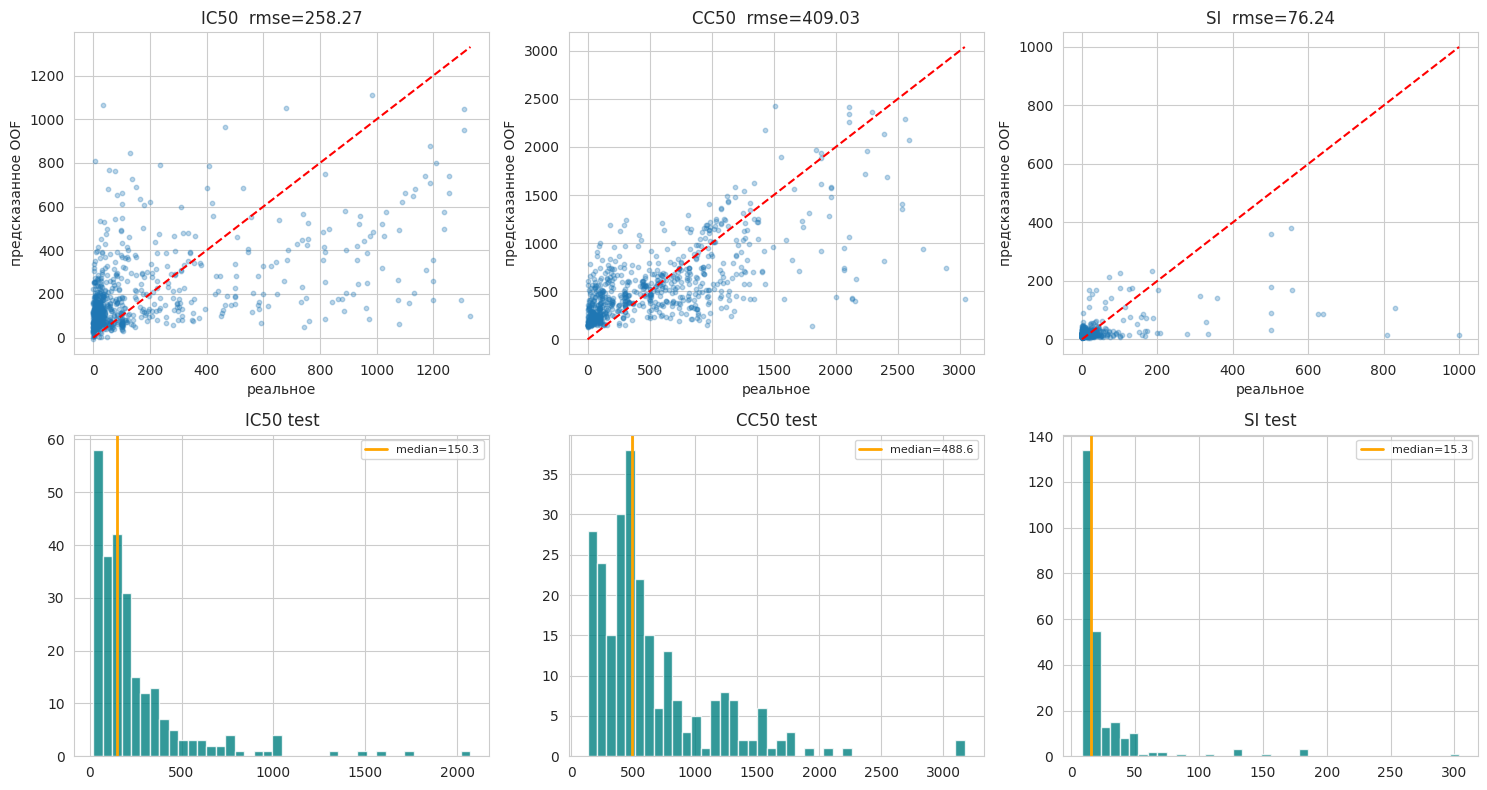

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (t_r, t_o) in enumerate(zip(TARGETS_REAL, TARGETS_OUT)):
    real = y_tr[t_r].values
    pred = final_oof[t_o]
    q99  = np.quantile(real, 0.99)
    mask = real < q99

    axes[0, i].scatter(real[mask], pred[mask], alpha=0.3, s=10)
    lim = max(real[mask].max(), pred[mask].max())
    axes[0, i].plot([0, lim], [0, lim], 'r--', lw=1.5)
    axes[0, i].set_xlabel('реальное')
    axes[0, i].set_ylabel('предсказанное OOF')
    axes[0, i].set_title(f'{t_o}  rmse={rmse(real[mask], pred[mask]):.2f}')

    axes[1, i].hist(final_te[t_o], bins=40, color='teal', alpha=0.8, edgecolor='white')
    axes[1, i].axvline(np.median(final_te[t_o]), color='orange', lw=2,
                       label=f'median={np.median(final_te[t_o]):.1f}')
    axes[1, i].set_title(f'{t_o} test')
    axes[1, i].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Шаг 11. Важность признаков

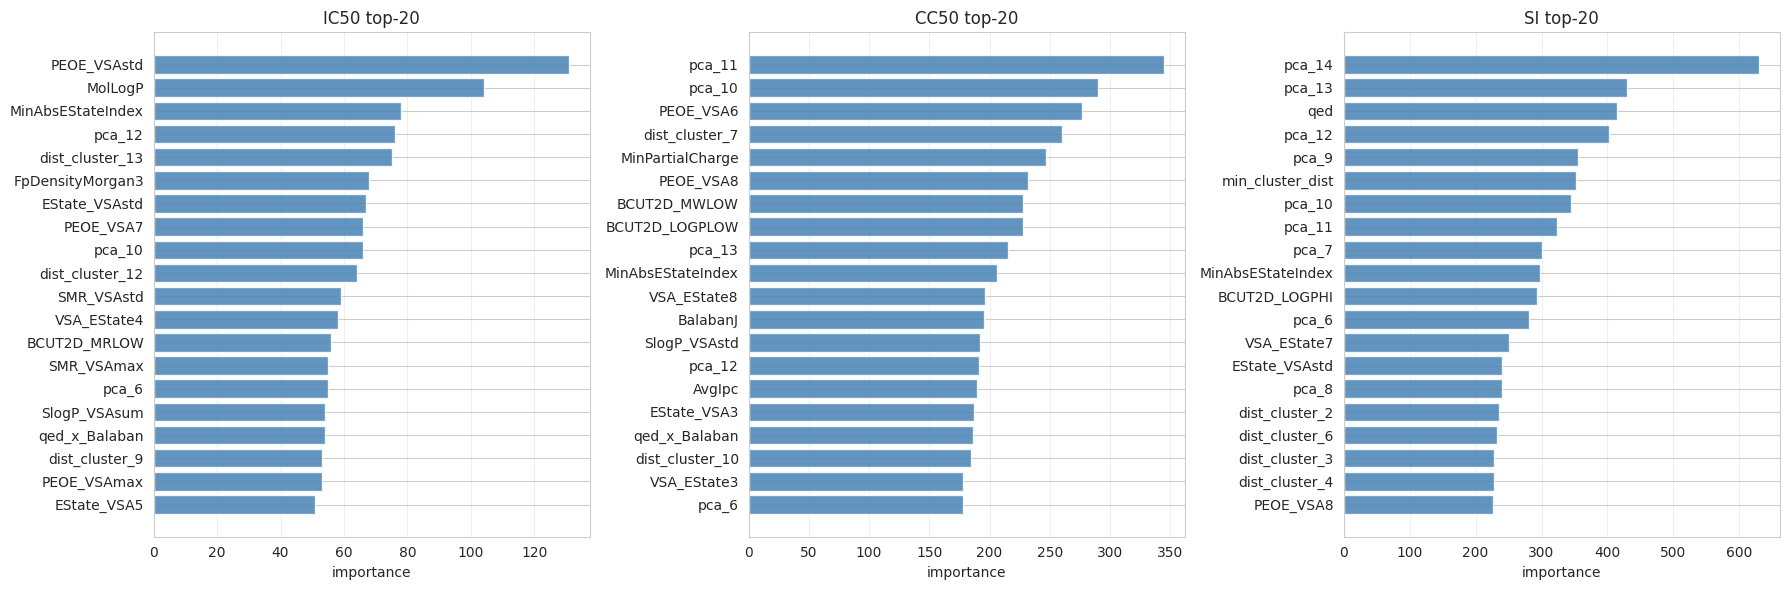

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (t_r, t_o) in zip(axes, zip(TARGETS_REAL, TARGETS_OUT)):
    p = dict(BEST_LGB[t_r], random_state=SEED)
    m = lgb.LGBMRegressor(**p)
    y_fit = np.log1p(y_tr[t_r]) if USE_LOG[t_r] else y_tr[t_r]
    if t_r == 'SI':
        mask = y_tr[t_r] < SI_OUTLIER_THRESHOLD
        m.fit(X_tr[mask], y_fit[mask])
    else:
        m.fit(X_tr, y_fit)

    imp = pd.Series(m.feature_importances_, index=X_tr.columns).sort_values(ascending=False).head(20)
    ax.barh(imp.index[::-1], imp.values[::-1], color='steelblue', alpha=0.85)
    ax.set_title(f'{t_o} top-20')
    ax.set_xlabel('importance')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## Шаг 12. Submission

In [ ]:
submission = pd.DataFrame({'index': test['index'].values})
for t_o in TARGETS_OUT:
    submission[t_o] = np.clip(final_te[t_o], 0, None)

submission.head()


In [35]:
submission[TARGETS_OUT].describe().round(2)


,IC50,CC50,SI
count,250.00,250.00,250.00
mean,247.02,644.21,24.81
std,287.89,479.20,32.02
min,19.83,133.34,8.42
25%,77.53,325.16,11.62
50%,150.25,488.59,15.26
75%,300.40,772.30,23.06
max,2071.67,3172.37,303.65


In [36]:
LOCAL_SUB  = '/content/submission_v10.csv'
GDRIVE_SUB = DATA_DIR + 'submission_v10.csv'
submission.to_csv(LOCAL_SUB, index=False)
submission.to_csv(GDRIVE_SUB, index=False)

from google.colab import files
files.download(LOCAL_SUB)
print('файл сохранён')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

файл сохранён


## Шаг 13. Выводы

Построена модель предсказания биологической активности химических соединений.

**Что сделано:**
- Проведён анализ данных: распределения, выбросы, корреляции, проверка схожести train и test
- Удалены константные, дублирующиеся и высококоррелированные признаки
- Добавлены новые признаки: молекулярные соотношения, агрегаты дескрипторов, кластеры, PCA
- Подобраны гиперпараметры через Optuna отдельно для каждого таргета
- Обучен ансамбль LightGBM + CatBoost + XGBoost с Ridge stacking
- 10-Fold CV × 10 seeds с взвешенным усреднением

**Главные находки:**
- Фильтрация выбросов SI >= 700 при обучении жто основной прирост качества.
  В train есть значения до 15620, в test их нет, модель обучалась предсказывать то чего в test нет
- CC50 лучше предсказывается в log-пространстве
- Кластеры KMeans добавляют полезную информацию о структурной принадлежности молекул

**Что проверялось и не помогло:**
- Log-трансформация всех таргетов сразу, CV ухудшился
- Pseudo-labeling — небольшой прирост, но синтетические данные в обучении нежелательны
- Winsorize таргетов, хуже
- SVR, нейросети, хуже бустингов


